# 접선의 방정식

곡선 $y = f(x)$ 위 점 $(a,\, f(a))$에서의 접선:

$$
y - f(a) = f'(a)\,(x - a)
$$

즉 기울기가 미분계수 $f'(a)$인 직선이다.

## 1. 접선 구하기

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x = sp.symbols('x')

f = x**3 + x**2 + x + 1
df = sp.diff(f, x)
a = 2

fa = f.subs(x, a)
fpa = df.subs(x, a)
# y - f(a) = f'(a)(x - a)
tangent = fa + fpa * (x - a)

print("점:")
display((a, fa))
print("기울기 f'(a):")
display(fpa)
print("접선 y =")
display(sp.expand(tangent))
print("방정식:")
display(sp.Eq(sp.symbols('y'), sp.expand(tangent)))

점:


기울기 f'(a):


접선 y =


방정식:


**접선 공식**: <br>
=> $y = f(a) + f'(a)(x-a)$

**sp.expand**: <br>
=> $mx+b$ 형태로 정리

## 2. 여러 점에서의 접선

In [2]:
f_num = sp.lambdify(x, f, 'numpy')
df_num = sp.lambdify(x, df, 'numpy')

points = [-1, 0, 1, 2]
for a0 in points:
    t_expr = f.subs(x, a0) + df.subs(x, a0) * (x - a0)
    print(f"a={a0}: y = {sp.expand(t_expr)}")

a=-1: y = 2*x + 2
a=0: y = x + 1
a=1: y = 6*x - 2
a=2: y = 17*x - 19


## 3. 그래프

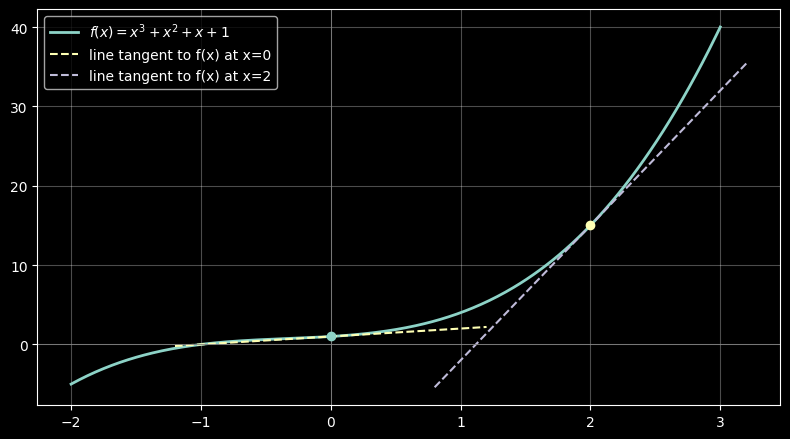

In [5]:
xs = np.linspace(-2, 3, 400)
ys = f_num(xs)

plt.figure(figsize=(8, 4.5))
plt.plot(xs, ys, label=r"$f(x)=x^3+x^2+x+1$", lw=2)

for a0 in [0, 2]:
    slope = df_num(a0)
    y0 = f_num(a0)
    xx = np.linspace(a0 - 1.2, a0 + 1.2, 50)
    plt.plot(xx, y0 + slope * (xx - a0), ls="--", label=f"line tangent to f(x) at x={a0}")
    plt.scatter([a0], [y0], zorder=5)

plt.axhline(0, color="gray", lw=0.6)
plt.axvline(0, color="gray", lw=0.6)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 접선이 수평인 점 ($f'(a)=0$)

In [4]:
crit = sp.solve(sp.Eq(df, 0), x)
print("f'(x)=0인 x:")
display(crit)
for c in crit:
    if c.is_real:
        print(f"점 ({c}, {f.subs(x,c)}), 접선: y = {f.subs(x,c)}")

f'(x)=0인 x:
